Procesando datos...
Año 2019 procesado.
Año 2021 procesado.
Año 2024 procesado.
Año 2025 procesado.
Generando gráficos en pantalla...


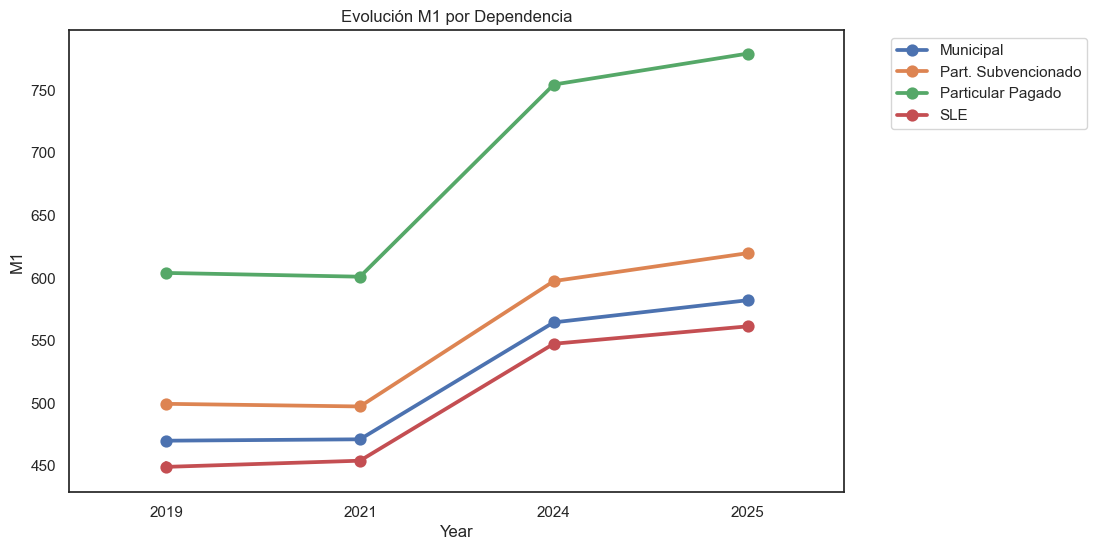

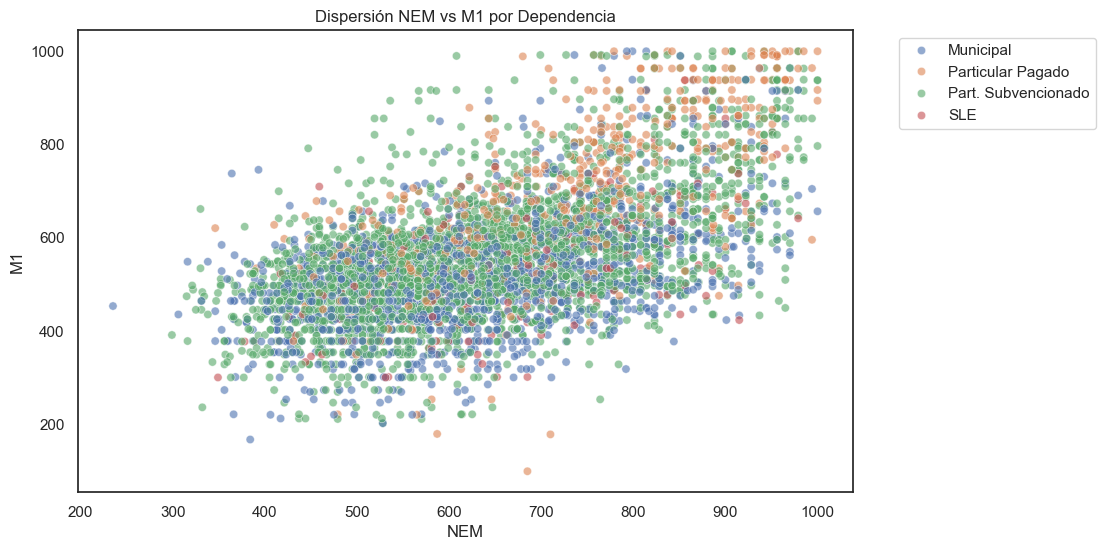

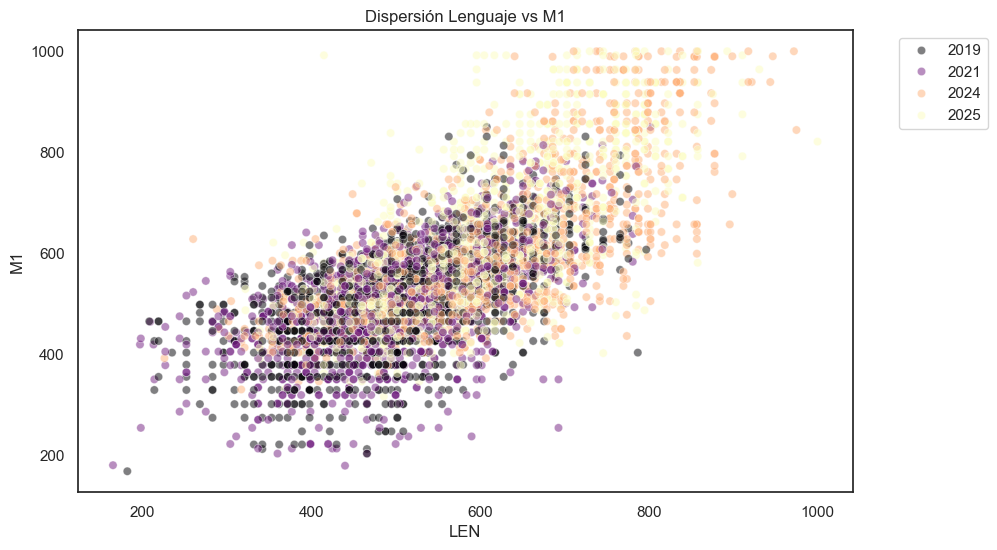

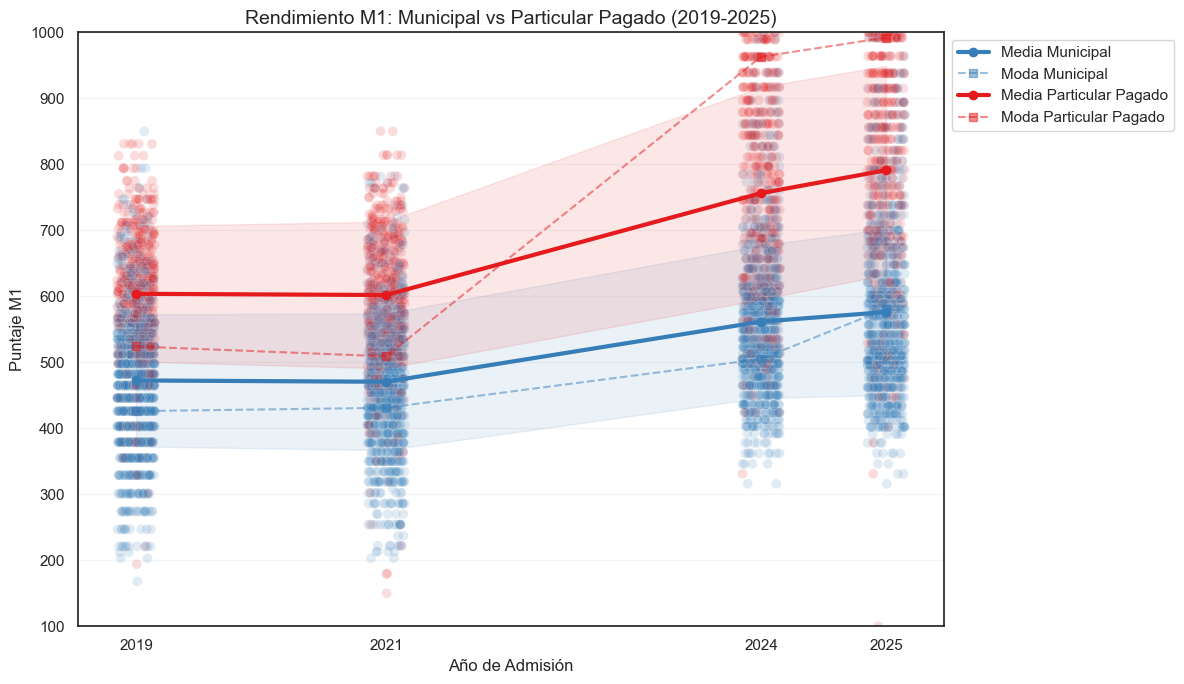

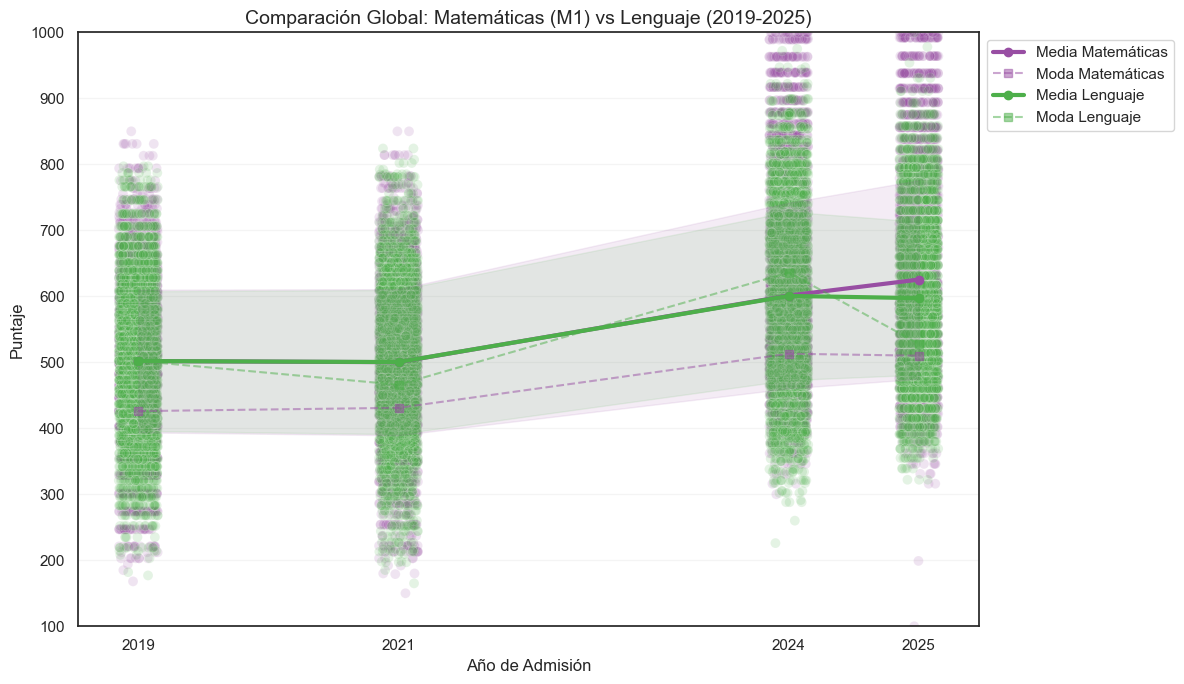

¡Proceso terminado!


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="white") 

# Mapeos y diccionarios
colores_genero = {'Hombre': '#1b9e77', 'Mujer': '#d95f02'}
dep_map = {1: 'Particular Pagado', 2: 'Part. Subvencionado', 3: 'Municipal', 4: 'SLE'}

config_pruebas = {
    'M1': {2019: ['MATE_ACTUAL'], 2021: ['MATE_ACTUAL'], 2024: ['MATE1_REG_ACTUAL'], 2025: ['MATE1_REG_ACTUAL']},
    'LEN': {2019: ['LENG_ACTUAL', 'CLEC_ACTUAL'], 2021: ['CLEC_ACTUAL', 'LENG_ACTUAL'], 2024: ['CLEC_REG_ACTUAL'], 2025: ['CLEC_REG_ACTUAL']},
    'NEM': {2019: ['PTJE_NEM'], 2021: ['PTJE_NEM'], 2024: ['PTJE_NEM'], 2025: ['PTJE_NEM']}
}
posibles_dep = ['GRUPO_DEPENDENCIA', 'COD_DEPENDENCIA', 'DEPENDENCIA']

def clean_score(s):
    if pd.isna(s) or s == '': return np.nan
    if isinstance(s, str): s = s.replace(',', '.')
    try:
        val = float(s)
        return val if val > 0 else np.nan
    except: return np.nan

def buscar_archivo(nombre):
    rutas = [os.path.join('csv', nombre), os.path.join('..', 'csv', nombre), nombre]
    for r in rutas:
        if os.path.exists(r): return r
    return None

años = [2019, 2021, 2024, 2025]
all_data = []

print("Procesando datos...")

for año in años:
    ruta_b = buscar_archivo(f'ArchivoB_Adm{año}.csv')
    ruta_c = buscar_archivo(f'ArchivoC_Adm{año}.csv')
    
    if ruta_b and ruta_c:
        # Extraer cabeceras limpias
        cols_b_raw = pd.read_csv(ruta_b, sep=';', nrows=0).columns.tolist()
        cols_c_raw = pd.read_csv(ruta_c, sep=';', nrows=0).columns.tolist()
        cols_b_cl = [c.strip().replace('"', '') for c in cols_b_raw]
        cols_c_cl = [c.strip().replace('"', '') for c in cols_c_raw]
        
        # Seleccionar columnas para Archivo B
        usecols_b = ['ID_aux']
        if 'SEXO' in cols_b_cl: usecols_b.append('SEXO')
        col_dep_b = next((c for c in posibles_dep if c in cols_b_cl), None)
        if col_dep_b: usecols_b.append(col_dep_b)
            
        df_b = pd.read_csv(ruta_b, sep=';', usecols=usecols_b, low_memory=False)
        df_b.columns = df_b.columns.str.strip().str.replace('"', '')

        # Seleccionar columnas para Archivo C
        usecols_c = ['ID_aux']
        col_m1 = next((c for c in config_pruebas['M1'][año] if c in cols_c_cl), None)
        col_len = next((c for c in config_pruebas['LEN'][año] if c in cols_c_cl), None)
        col_nem = next((c for c in config_pruebas['NEM'][año] if c in cols_c_cl), None)
        
        if col_m1: usecols_c.append(col_m1)
        if col_len: usecols_c.append(col_len)
        if col_nem: usecols_c.append(col_nem)
        
        col_dep_c = None
        if not col_dep_b:
            col_dep_c = next((c for c in posibles_dep if c in cols_c_cl), None)
            if col_dep_c: usecols_c.append(col_dep_c)
            
        df_c = pd.read_csv(ruta_c, sep=';', usecols=usecols_c, low_memory=False)
        df_c.columns = df_c.columns.str.strip().str.replace('"', '')

        # Merge de DataFrames reducidos
        df_merged = pd.merge(df_c, df_b, on='ID_aux')
        
        # Construcción limpia
        df_yr = pd.DataFrame()
        df_yr['Year'] = [año] * len(df_merged)
        
        if col_m1: df_yr['M1'] = df_merged[col_m1].apply(clean_score)
        if col_len: df_yr['LEN'] = df_merged[col_len].apply(clean_score)
        if col_nem: df_yr['NEM'] = df_merged[col_nem].apply(clean_score)
        
        col_dep_final = col_dep_b or col_dep_c
        if col_dep_final: 
            df_yr['Dependencia'] = df_merged[col_dep_final].map(dep_map)
            
        if 'SEXO' in df_merged.columns:
            df_yr['Genero'] = df_merged['SEXO'].map({1: 'Hombre', 2: 'Mujer'})
            
        all_data.append(df_yr.dropna(subset=['M1']))
        print(f"Año {año} procesado.")

df_final = pd.concat(all_data).reset_index(drop=True)
df_sample = df_final.sample(n=min(5000, len(df_final)), random_state=42)

print("Generando gráficos en pantalla...")

# 2. Pointplot: Dependencia
plt.figure(figsize=(10, 6))
sns.pointplot(data=df_final, x='Year', y='M1', hue='Dependencia')
plt.title('Evolución M1 por Dependencia')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show() # <-- Muestra el gráfico en Jupyter




# ==========================================
# NUEVOS GRÁFICOS: LÍNEA DE TIEMPO CON DISPERSIÓN
# ==========================================

np.random.seed(42)
df_pts = df_final.sample(n=min(15000, len(df_final))).copy()
años_unicos = sorted(df_pts['Year'].unique())

# --- 5. Dispersión Línea de Tiempo: M1 por Dependencia (Municipal vs Particular Pagado) ---
df_dep = df_pts[df_pts['Dependencia'].isin(['Municipal', 'Particular Pagado'])].copy()
df_dep['Año_Jitter'] = df_dep['Year'] + np.random.uniform(-0.15, 0.15, size=len(df_dep))

stats_dep = df_dep.groupby(['Year', 'Dependencia'])['M1'].agg(
    Media='mean',
    Std='std',
    Moda=lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
).reset_index()

stats_dep['Std_Inf'] = stats_dep['Media'] - stats_dep['Std']
stats_dep['Std_Sup'] = stats_dep['Media'] + stats_dep['Std']

colores_dep = {'Municipal': '#377eb8', 'Particular Pagado': '#e41a1c'}

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_dep, x='Año_Jitter', y='M1', hue='Dependencia', 
    palette=colores_dep, alpha=0.15, s=50, legend=False
)

for dep in ['Municipal', 'Particular Pagado']:
    color = colores_dep[dep]
    data_g = stats_dep[stats_dep['Dependencia'] == dep]
    plt.fill_between(data_g['Year'], data_g['Std_Inf'], data_g['Std_Sup'], color=color, alpha=0.1)
    plt.plot(data_g['Year'], data_g['Media'], marker='o', color=color, lw=3, label=f'Media {dep}')
    plt.plot(data_g['Year'], data_g['Moda'], marker='s', ls='--', color=color, alpha=0.5, label=f'Moda {dep}')

plt.ylim(100, 1000)
plt.title('Rendimiento M1: Municipal vs Particular Pagado (2019-2025)', fontsize=14)
plt.ylabel('Puntaje M1')
plt.xlabel('Año de Admisión')
plt.xticks(años_unicos)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

# --- 6. Dispersión Línea de Tiempo: M1 vs Lenguaje ---
df_materias = df_pts.melt(id_vars=['Year'], value_vars=['M1', 'LEN'], var_name='Materia', value_name='Puntaje').dropna()
df_materias['Año_Jitter'] = df_materias['Year'] + np.random.uniform(-0.15, 0.15, size=len(df_materias))

stats_mat = df_materias.groupby(['Year', 'Materia'])['Puntaje'].agg(
    Media='mean',
    Std='std',
    Moda=lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
).reset_index()

stats_mat['Std_Inf'] = stats_mat['Media'] - stats_mat['Std']
stats_mat['Std_Sup'] = stats_mat['Media'] + stats_mat['Std']

colores_mat = {'M1': '#984ea3', 'LEN': '#4daf4a'}

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_materias, x='Año_Jitter', y='Puntaje', hue='Materia', 
    palette=colores_mat, alpha=0.15, s=50, legend=False
)

for mat, label in zip(['M1', 'LEN'], ['Matemáticas', 'Lenguaje']):
    color = colores_mat[mat]
    data_g = stats_mat[stats_mat['Materia'] == mat]
    plt.fill_between(data_g['Year'], data_g['Std_Inf'], data_g['Std_Sup'], color=color, alpha=0.1)
    plt.plot(data_g['Year'], data_g['Media'], marker='o', color=color, lw=3, label=f'Media {label}')
    plt.plot(data_g['Year'], data_g['Moda'], marker='s', ls='--', color=color, alpha=0.5, label=f'Moda {label}')

plt.ylim(100, 1000)
plt.title('Comparación Global: Matemáticas (M1) vs Lenguaje (2019-2025)', fontsize=14)
plt.ylabel('Puntaje')
plt.xlabel('Año de Admisión')
plt.xticks(años_unicos)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

print("¡Proceso terminado!")